In [207]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import numpy as np

In [208]:
train_df = pd.read_csv('/content/gadgets_train.csv')
test_df = pd.read_csv('/content/gadgets_test.csv')

In [209]:
train_df_shape = train_df.shape
test_df_shape = test_df.shape

print(f"Train DataFrame shape -> {train_df_shape}")
print(f"Test DataFrame shape -> {test_df_shape}")
# Train va test datasetlarining qator va ustunlar sonini tekshirish.

Train DataFrame shape -> (1500, 16)
Test DataFrame shape -> (400, 16)


In [210]:
train_df.head()

,gadget_id,device_type,brand,release_date,screen_size_inches,ram_gb,storage_gb,battery_mah,weight_grams,build_quality,os,has_5g,rating,reviews_count,warranty_months,price_usd
0,GDG-00001,Smartphone,OnePlus,2024-08-02,5.9,8,256,5018,182.0,Budget,Android,0,3.8,752,12,362.66
1,GDG-00002,Smartphone,Xiaomi,2025-02-17,5.9,16,256,5016,231.4,Budget,Android,0,3.6,258,12,524.77
2,GDG-00003,Laptop,Asus,2023-05-15,13.4,16,512,4883,1428.0,Budget,Windows,0,3.7,1171,12,957.95
3,GDG-00004,Wireless Earbuds,Apple,2022-02-12,0.0,0,0,118,56.0,Budget,Proprietary,0,4.0,95,24,111.18
4,GDG-00005,Wireless Earbuds,Sony,2023-05-10,0.0,0,0,63,48.5,Mid-Range,Proprietary,0,3.4,1144,24,123.75


In [211]:
train_df.tail()

,gadget_id,device_type,brand,release_date,screen_size_inches,ram_gb,storage_gb,battery_mah,weight_grams,build_quality,os,has_5g,rating,reviews_count,warranty_months,price_usd
1495,GDG-01496,Laptop,Lenovo,2023-07-15,15.8,8,256,7776,2110.0,Mid-Range,Windows,1,4.1,7378,24,1100.93
1496,GDG-01497,Wireless Earbuds,Sony,2025-12-14,0.0,0,0,43,40.7,Flagship,Proprietary,0,4.6,2649,12,91.66
1497,GDG-01498,Smartphone,Xiaomi,2025-12-16,6.3,4,128,3664,191.3,High-End,Android,1,3.8,607,6,401.66
1498,GDG-01499,Laptop,Dell,2022-01-02,14.5,16,512,8418,1215.4,High-End,Windows,0,4.2,782,12,1693.82
1499,GDG-01500,Tablet,Apple,2021-10-31,11.4,4,512,7673,607.4,Budget,iPadOS,1,4.2,845,12,835.87


In [212]:
data_types = train_df.dtypes

print(f"Data Types: \n{data_types.round(2)}")
# Ustunlarning ma'lumot turlarini tekshirish.

Data Types: 
gadget_id              object
device_type            object
brand                  object
release_date           object
screen_size_inches    float64
ram_gb                  int64
storage_gb              int64
battery_mah             int64
weight_grams          float64
build_quality          object
os                     object
has_5g                  int64
rating                float64
reviews_count           int64
warranty_months         int64
price_usd             float64
dtype: object


In [213]:
info = train_df.info()

print(f"Data Info: \n{info}")
# Dataset ustunlari, ma'lumot turlari va bo'sh bo'lmagan qiymatlar sonini ko'rish.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gadget_id           1500 non-null   object 
 1   device_type         1500 non-null   object 
 2   brand               1500 non-null   object 
 3   release_date        1500 non-null   object 
 4   screen_size_inches  1500 non-null   float64
 5   ram_gb              1500 non-null   int64  
 6   storage_gb          1500 non-null   int64  
 7   battery_mah         1500 non-null   int64  
 8   weight_grams        1500 non-null   float64
 9   build_quality       1500 non-null   object 
 10  os                  1500 non-null   object 
 11  has_5g              1500 non-null   int64  
 12  rating              1500 non-null   float64
 13  reviews_count       1500 non-null   int64  
 14  warranty_months     1500 non-null   int64  
 15  price_usd           1500 non-null   float64
dtypes: flo

In [214]:
nulls_sum = train_df.isnull().sum().sum()

print(f"Nulls count: {nulls_sum}")
# Datasetdagi jami bo'sh qiymatlar sonini hisoblash.

Nulls count: 0


In [215]:
print("Describe:\n", train_df.describe().round(2))

Describe:
        screen_size_inches   ram_gb  storage_gb  battery_mah  weight_grams  \
count             1500.00  1500.00     1500.00      1500.00       1500.00   
mean                 8.06     8.22      272.03      4592.33        632.33   
std                  5.22     8.37      304.56      2748.01        758.09   
min                  0.00     0.00        0.00        35.00         32.30   
25%                  5.90     4.00       64.00      3686.50        166.40   
50%                  6.60     6.00      128.00      4784.00        214.05   
75%                 13.70     8.00      512.00      6320.75        775.68   
max                 17.30    64.00     2048.00     11140.00       2599.40   

        has_5g   rating  reviews_count  warranty_months  price_usd  
count  1500.00  1500.00        1500.00          1500.00    1500.00  
mean      0.43     3.93        1241.25            14.68     787.70  
std       0.50     0.45        1247.71             7.00     624.33  
min       0.00     

In [216]:
Q1, Q3 = train_df['price_usd'].quantile([0.25, 0.75])
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_df[(train_df['price_usd'] < lower_bound) | (train_df['price_usd'] > upper_bound)]

print(f"Outliers count for price usd: {len(outliers)}")
print(f"Lower Bound: {lower_bound}$")
print(f"Upper Bound: {upper_bound}$")

# IQR usuli yordamida narx ustunidagi noodatiy qiymatlarni aniqlash.

Outliers count for price usd: 80
Lower Bound: -621.33$
Upper Bound: 2011.95$


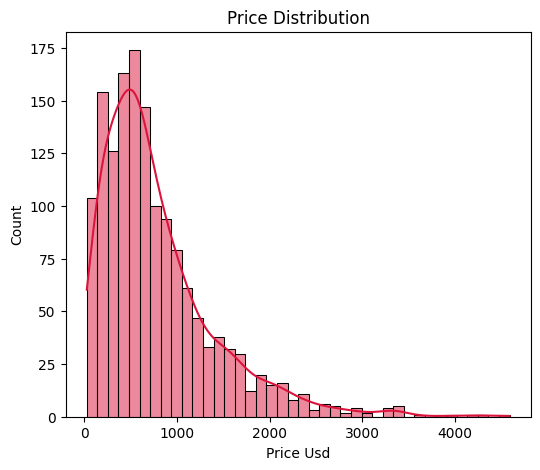

In [217]:
plt.figure(figsize=(6, 5))
sns.histplot(data = train_df, x = 'price_usd', kde=True, color='crimson')
plt.xlabel("Price Usd")
plt.title('Price Distribution')
plt.show()

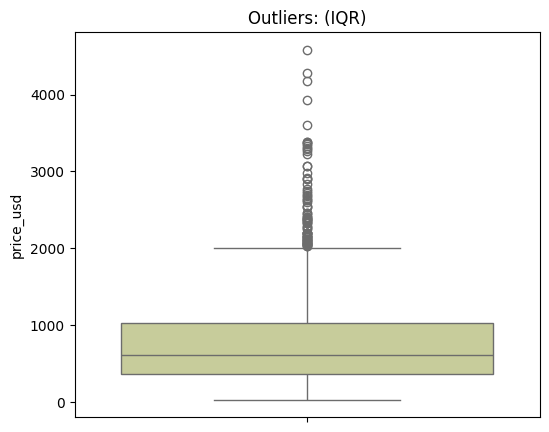

In [218]:
plt.figure(figsize=(6, 5))
sns.boxplot(data = train_df, y = 'price_usd', color='#CED493')
plt.title("Outliers: (IQR)")
plt.show()

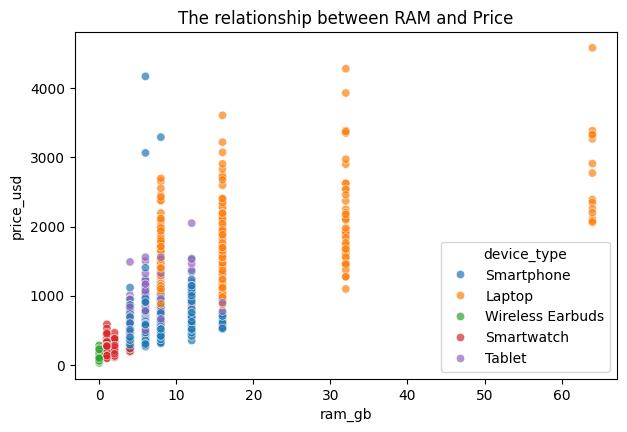

In [219]:
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=train_df, x='ram_gb', y='price_usd', hue='device_type', alpha=0.7)
plt.title("The relationship between RAM and Price")
plt.show()

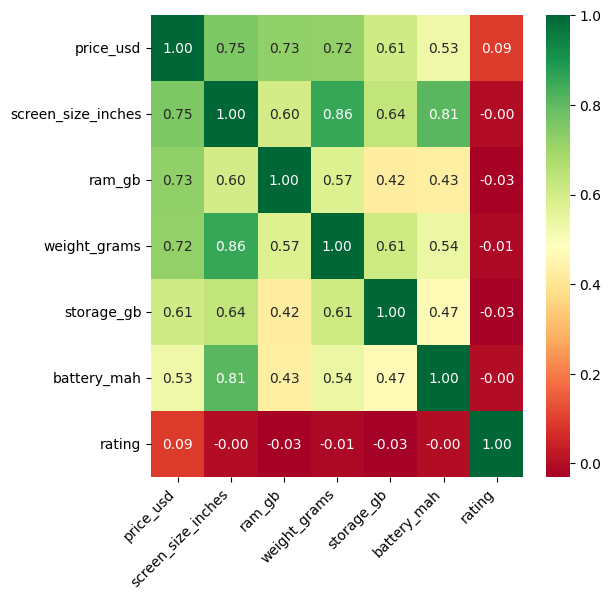

In [220]:
nums = train_df.select_dtypes(include=['number'])

top_corr = nums.corr()['price_usd'].sort_values(ascending=False).head(7).index

plt.figure(figsize=(6, 6))
sns.heatmap(nums[top_corr].corr(), annot=True, fmt='.2f', cmap='RdYlGn')
plt.xticks(rotation=45, ha='right')
plt.show()

In [221]:
stat, p_val = sp.stats.shapiro(train_df['price_usd'])
print(f"Shapiro-Wilk: W = {stat:.4f}, p-value = {p_val}")

mean_p = train_df['price_usd'].mean()
sem_p = sp.stats.sem(train_df['price_usd'])
ci_95 = sp.stats.t.interval(0.95, len(train_df)-1, loc=mean_p, scale=sem_p)
print(f"Mean Price ${mean_p:.2f}")
print(f"95% Confidence Interval: (${ci_95[0]:.2f}, ${ci_95[1]:.2f})")

apple_prices = train_df[train_df['brand'] == 'Apple']['price_usd']
samsung_prices = train_df[train_df['brand'] == 'Samsung']['price_usd']

t_stat, p_ttest = sp.stats.ttest_ind(apple_prices, samsung_prices, equal_var=False)
print(f"T-test result: t={t_stat:.3f}, p-value={p_ttest:.4e}")

# Narxlarning normal taqsimotini, o'rtacha narxning 95% ishonch oralig'ini va Apple hamda Samsung narxlari farqini statistik tekshirish.

Shapiro-Wilk: W = 0.8512, p-value = 2.175295776709419e-35
Mean Price $787.70
95% Confidence Interval: ($756.08, $819.32)
T-test result: t=8.080, p-value=6.4851e-15


In [222]:
target_col = 'price_usd'

X_train = train_df.drop(columns=[target_col])
X_test = test_df.drop(columns=[target_col])

y_train = train_df[target_col]
y_test = test_df[target_col]

print(f"X train size: {X_train.shape}")
print(f"X test size: {X_test.shape}")
print(f"y train size: {y_train.shape}")
print(f"y test size: {y_test.shape}")
# Belgilar (X) va (y) ni train va test datasetlariga ajratish.

X train size: (1500, 15)
X test size: (400, 15)
y train size: (1500,)
y test size: (400,)


In [223]:
drop_cols = ['gadget_id']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print(f"X train size after drop: {X_train.shape}")
print(f"X test size after drop: {X_test.shape}")
# Model uchun foydasiz bo‘lgan gadget_id ustunini train va test datasetlaridan olib tashlash.

X train size after drop: (1500, 14)
X test size after drop: (400, 14)


In [224]:
print(f"Existing columns: \n{X_train.columns}")

Existing columns: 
Index(['device_type', 'brand', 'release_date', 'screen_size_inches', 'ram_gb',
       'storage_gb', 'battery_mah', 'weight_grams', 'build_quality', 'os',
       'has_5g', 'rating', 'reviews_count', 'warranty_months'],
      dtype='object')


In [225]:
from datetime import date
def feature_engineering(df):
  df = df.copy()

  release_years = pd.to_datetime(df['release_date']).dt.year
  current_year = date.today().year
  df['gadget_age'] = current_year - release_years

  df['battery_per_weight'] = df['battery_mah'] / (df['weight_grams'] + 1e-5)
  df['ram_per_storage'] = df['ram_gb'] / (df['storage_gb'] + 1)

  df = df.drop(columns=['release_date'])

  return df


X_train = feature_engineering(X_train)
X_test = feature_engineering(X_test)

print(f"New X Train size: {X_train.shape}")
print(f"New X Test size: {X_test.shape}")
# Yangi xususiyatlar yaratish va release_date ustunini olib tashlash orqali model uchun ma'lumotlarni tayyorlash.

New X Train size: (1500, 16)
New X Test size: (400, 16)


In [226]:
X_train[['gadget_age', 'battery_per_weight', 'ram_per_storage']].head(10)

,gadget_age,battery_per_weight,ram_per_storage
0,2,27.571427,0.031128
1,1,21.676749,0.062257
2,3,3.419468,0.031189
3,4,2.107142,0.000000
4,3,1.298969,0.000000
5,4,15.917534,0.062016
6,3,6.889399,0.121212
7,1,12.139008,0.062016
8,4,31.510701,0.092308
9,3,23.490162,0.046693


In [227]:
X_train['build_quality'].value_counts()

,count
build_quality,
Mid-Range,607
Budget,385
High-End,366
Flagship,142


In [228]:
from sklearn.preprocessing import OneHotEncoder

quality_mapping = {
    'Budget' : 1,
    "Mid-Range" : 2,
    "High-End" : 3,
    "Flagship" : 4
}

X_train['build_quality'] = X_train['build_quality'].map(quality_mapping)
X_test['build_quality'] = X_test['build_quality'].map(quality_mapping)

ohe_cols = ['device_type', 'brand', 'os']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_encoded = ohe.fit_transform(X_train[ohe_cols])
test_encoded = ohe.transform(X_test[ohe_cols])

encoded_feature_names = ohe.get_feature_names_out(ohe_cols)

df_train_encoded = pd.DataFrame(train_encoded, columns=encoded_feature_names, index=X_train.index)
df_test_encoded = pd.DataFrame(test_encoded, columns=encoded_feature_names, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=ohe_cols), df_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=ohe_cols), df_test_encoded], axis=1)

print(f"X Train shape after ENCODING: {X_train.shape}")
print(f"X Test shape after ENCODING: {X_test.shape}")
# Kategorik ma'lumotlarni raqamli formatga o'tkazish va model uchun tayyorlash.
# build_quality ustuni Ordinal Encoding, device_type, brand va os ustunlari One-Hot Encoding orqali o‘zgartirildi.

X Train shape after ENCODING: (1500, 41)
X Test shape after ENCODING: (400, 41)


In [229]:
X_train.columns

Index(['screen_size_inches', 'ram_gb', 'storage_gb', 'battery_mah',
       'weight_grams', 'build_quality', 'has_5g', 'rating', 'reviews_count',
       'warranty_months', 'gadget_age', 'battery_per_weight',
       'ram_per_storage', 'device_type_Laptop', 'device_type_Smartphone',
       'device_type_Smartwatch', 'device_type_Tablet',
       'device_type_Wireless Earbuds', 'brand_Apple', 'brand_Asus',
       'brand_Bose', 'brand_Dell', 'brand_Garmin', 'brand_Google', 'brand_HP',
       'brand_Huawei', 'brand_JBL', 'brand_Lenovo', 'brand_OnePlus',
       'brand_Samsung', 'brand_Sony', 'brand_Xiaomi', 'os_Android', 'os_Linux',
       'os_Proprietary', 'os_WearOS', 'os_Windows', 'os_iOS', 'os_iPadOS',
       'os_macOS', 'os_watchOS'],
      dtype='object')

In [230]:
from sklearn.preprocessing import StandardScaler, RobustScaler

robust_cols = ['reviews_count']

standard_cols = [
    'screen_size_inches', 'ram_gb', 'storage_gb', 'battery_mah',
    'weight_grams', 'rating', 'warranty_months', 'gadget_age',
    'battery_per_weight', 'ram_per_storage'
]

rs = RobustScaler()
ss = StandardScaler()

X_train[robust_cols] = rs.fit_transform(X_train[robust_cols])
X_test[robust_cols] = rs.transform(X_test[robust_cols])

X_train[standard_cols] = ss.fit_transform(X_train[standard_cols])
X_test[standard_cols] = ss.transform(X_test[standard_cols])

print("Scaling successfully completed!")
print(X_train[standard_cols].mean().round(2))
# reviews_count uchun RobustScaler, qolgan sonli ustunlar uchun StandardScaler qo‘llab, qiymatlarni masshtablash.

Scaling successfully completed!
screen_size_inches   -0.0
ram_gb                0.0
storage_gb            0.0
battery_mah           0.0
weight_grams          0.0
rating                0.0
warranty_months       0.0
gadget_age           -0.0
battery_per_weight    0.0
ram_per_storage       0.0
dtype: float64


In [231]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

baseline_preds = baseline.predict(X_test)

base_mae = mean_absolute_error(y_test, baseline_preds)
base_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
base_r2 = r2_score(y_test, baseline_preds)

print("--- BASELINE RESULTS ---")
print(f"MAE : ${base_mae:.2f}")
print(f"RMSE: ${base_rmse:.2f}")
print(f"R²  : {base_r2:.4f}")
# DummyRegressor yordamida o‘rtacha narxga asoslangan baseline model yaratildi va MAE, RMSE, R² bilan baholandi.
# MAE = $502.12, RMSE = $698.66, R² = -0.0023. Model narxlarni yaxshi bashorat qilmaydi.

--- BASELINE RESULTS ---
MAE : $502.12
RMSE: $698.66
R²  : -0.0023


In [232]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')

print("--- 5-FOLD CROSS-VALIDATION RESULT ---")
print("R² for every fold:", cv_scores.round(3))
print(f"Mean R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

model.fit(X_train, y_train)

print("\n--- TRAIN vs TEST COMPARE ---")
print(f"Train R²: {model.score(X_train, y_train):.4f}")
print(f"Test R² : {model.score(X_test, y_test):.4f}")

# Linear Regression modeli 5-Fold Cross-Validation orqali tekshirildi.
# O‘rtacha CV R² = 0.869, Train R² = 0.8728, Test R² = 0.8996. Model yaxshi natija ko‘rsatmoqda.

--- 5-FOLD CROSS-VALIDATION RESULT ---
R² for every fold: [0.919 0.843 0.89  0.793 0.897]
Mean R²: 0.869 ± 0.045

--- TRAIN vs TEST COMPARE ---
Train R²: 0.8728
Test R² : 0.8996


In [233]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)

    n = len(X_te)
    k = X_te.shape[1]
    r2_te = r2_score(y_te, pred_test)
    adj_r2 = 1 - (1 - r2_te) * (n - 1) / (n - k - 1)

    metrics = {
        "MAE ($)"         : mean_absolute_error(y_te, pred_test),
        "MedAE ($)"       : median_absolute_error(y_te, pred_test),
        "RMSE ($)"        : np.sqrt(mean_squared_error(y_te, pred_test)),
        "MAPE (%)"        : mean_absolute_percentage_error(y_te, pred_test) * 100,
        "R² (Test)"       : r2_te,
        "Adjusted R²"     : adj_r2,
        "R² (Train)"      : r2_score(y_tr, pred_train)
    }
    return pd.Series(metrics).round(2)

report = evaluate_model(model, X_train, X_test, y_train, y_test)
print(report)
# Model MAE, MedAE, RMSE, MAPE va R² metrikalari orqali baholandi.
# Baseline bilan solishtirganda, MAE $502.12 dan $135.79 ga, RMSE $698.66 dan $221.12 ga tushdi, R² esa -0.0023 dan 0.90 ga oshdi.

MAE ($)        135.79
MedAE ($)       91.93
RMSE ($)       221.12
MAPE (%)        33.74
R² (Test)        0.90
Adjusted R²      0.89
R² (Train)       0.87
dtype: float64


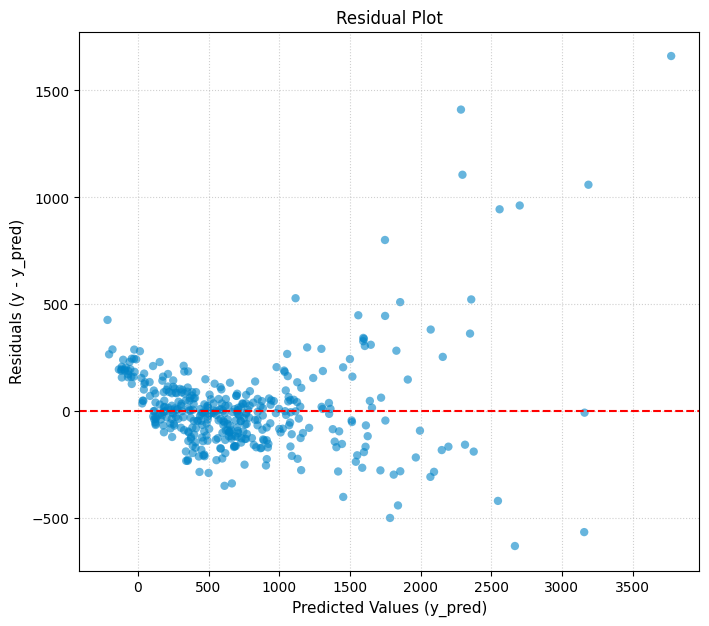

In [234]:
predictions = model.predict(X_test)
residuals = y_test - predictions

plt.figure(figsize=(8, 7))
plt.scatter(predictions, residuals, alpha=0.6, color='#0284c7', edgecolors='none')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)

plt.title("Residual Plot", fontsize=12)
plt.xlabel("Predicted Values (y_pred)", fontsize=11)
plt.ylabel("Residuals (y - y_pred)", fontsize=11)

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
# Residual Plot orqali bashorat xatolarining taqsimlanishi tekshirildi.
# Voronka shakli xatolar dispersiyasi narx qiymatiga qarab o‘zgarishini ko‘rsatishi mumkin.

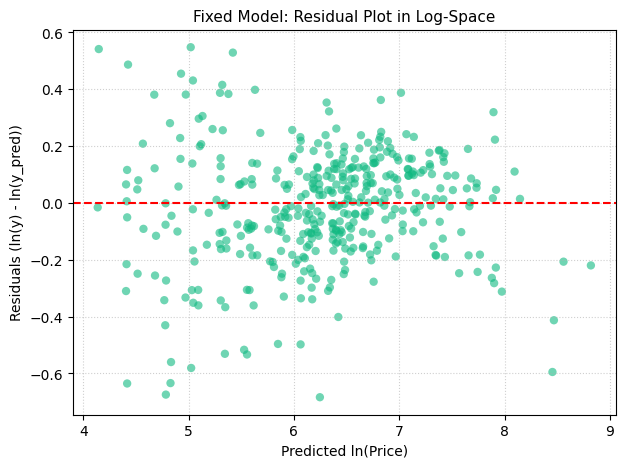

In [235]:
y_train_log = np.log(y_train)
model_log = LinearRegression().fit(X_train, y_train_log)

pred_log = model_log.predict(X_test)
final_preds = np.exp(pred_log)

residuals_dollar = y_test - pred_log
residuals_log = np.log(y_test) - pred_log

plt.figure(figsize=(7, 5))
plt.scatter(
    pred_log, residuals_log, alpha=0.6, color="#10b981", edgecolors="none"
)
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)

plt.title("Fixed Model: Residual Plot in Log-Space", fontsize=11)
plt.xlabel("Predicted ln(Price)", fontsize=10)
plt.ylabel("Residuals (ln(y) - ln(y_pred))", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()
# Narxlar log-transformatsiya qilinib, Linear Regression modeli qayta o‘qitildi va log-fazodagi residuals orqali xatolar taqsimoti tekshirildi.

In [236]:
pred_train = np.exp(model_log.predict(X_train))
pred_test = np.exp(model_log.predict(X_test))

n = len(X_test)
k = X_test.shape[1]
r2_te = r2_score(y_test, pred_test)
adj_r2 = 1 - (1 - r2_te) * (n - 1) / (n - k - 1)

report_log = pd.Series(
    {
        "MAE ($)": mean_absolute_error(y_test, pred_test),
        "MedAE ($)": median_absolute_error(y_test, pred_test),
        "RMSE ($)": np.sqrt(mean_squared_error(y_test, pred_test)),
        "MAPE (%)": mean_absolute_percentage_error(y_test, pred_test) * 100,
        "R² (Test)": r2_te,
        "Adjusted R²": adj_r2,
        "R² (Train)": r2_score(y_train, pred_train),
    }
).round(2)

print("--- RESULT AFTER LOG-TRANSFORMATION ---")
print(report_log)

# Log-transformatsiyadan keyin model natijalari oddiy Linear Regression bilan solishtirildi.
# MAE: $135.79 → $107.87, RMSE: $221.12 → $215.27, MAPE: 33.74% → 16.19%, R²: 0.90 → 0.90.
# Log-transformatsiya xatolarni kamaytirib, model aniqligini yaxshiladi.

--- RESULT AFTER LOG-TRANSFORMATION ---
MAE ($)        107.87
MedAE ($)       58.69
RMSE ($)       215.27
MAPE (%)        16.19
R² (Test)        0.90
Adjusted R²      0.89
R² (Train)       0.88
dtype: float64
